In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import f1_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
import shap
from sklearn.model_selection import cross_val_predict


In [5]:
client = pd.read_csv("Client.csv")
record = pd.read_csv("Record.csv")
print(f"For Clients, rows: {client.shape[0]}, columns: {client.shape[1]}")
print(f"For Records, rows: {record.shape[0]}, columns: {record.shape[1]}")

For Clients, rows: 100000, columns: 50
For Records, rows: 100000, columns: 51


## 1. Merge Data
Combine client details with usage records using Customer_ID.

In [6]:
# Inner join to only keep matching customers
df = record.merge(client, on='Customer_ID', how='inner')
print(f"rows: {df.shape[0]},columns: {df.shape[1]}")

rows: 100000,columns: 100


In [7]:
print(f"minimum: {df['change_rev'].min()}")
print(f"maximum: {df['change_rev'].max()}")
neg = df.query("change_rev < 0")['change_rev']
print(f"Mean less than 0 : {neg.mean()}")

minimum: -1107.74
maximum: 9963.6575
Mean less than 0 : -16.095977975660837


## 2. Define the Target
Remove churned users. Define a downgrade as a revenue drop of more than $10.

In [8]:
# Keep only active users
df = df[df['churn'] == 0].copy()
print(df.shape)

(50438, 100)


In [9]:
# 1 if revenue drops > $10, else 0
df['is_compressing'] = (df['change_rev'] < -10).astype(int)
print(f"Target distribution:\n{df['is_compressing'].value_counts(normalize=True)}")

Target distribution:
is_compressing
0    0.79567
1    0.20433
Name: proportion, dtype: float64


In [10]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0]*100/50438)

rev_Mean             0.222055
mou_Mean             0.222055
totmrc_Mean          0.222055
da_Mean              0.222055
ovrmou_Mean          0.222055
ovrrev_Mean          0.222055
vceovr_Mean          0.222055
datovr_Mean          0.222055
roam_Mean            0.222055
change_mou           0.422301
change_rev           0.422301
avg6mou              3.364527
avg6qty              3.364527
avg6rev              3.364527
prizm_social_one     7.093858
area                 0.027757
dualband             0.001983
refurb_new           0.001983
hnd_price            1.062691
phones               0.001983
models               0.001983
hnd_webcap           8.251715
truck                1.790317
rv                   1.790317
ownrent             32.727309
lor                 29.114953
dwlltype            30.895357
marital              1.790317
adults              22.034974
infobase            21.019866
income              24.491455
numbcars            48.709306
HHstatin            36.851184
dwllsize  

## 3. Clean Data
Drop columns with too many missing values and leaky variables (like current revenue).

In [11]:
# Drop features that leak the target
leaky_columns = [
    'Customer_ID', 'churn', 'change_rev','totrev', 'adjrev', 'avgrev', 'avg3rev', 'avg6rev'
]
heavily_missing_columns = [
    'numbcars', 'dwllsize', 'HHstatin', 'ownrent', 'dwlltype', 'lor'
]
df_clean = df.drop(columns=leaky_columns + heavily_missing_columns)

In [12]:
print(df_clean.shape)
print(df_clean.columns)

(50438, 87)
Index(['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
       'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou',
       'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean',
       'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean',
       'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean',
       'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inonemin_Mean',
       'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean',
       'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean',
       'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean',
       'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean', 'mou_opkv_Mean',
       'mou_opkd_Mean', 'drop_blk_Mean', 'attempt_Mean', 'complete_Mean',
       'callfwdv_Mean', 'callwait_Mean', 'months', 'uniqsubs', 'actvsubs',
       'new_cell', 'crclscod', 'asl_flag', 'totcalls', 'totmou', 'adjmou',
       'adjqty', 'avgmou',

In [13]:
skew_values = df_clean.select_dtypes(include=['float64', 'int64']).skew()

print(skew_values.sort_values(ascending=False).to_string())

blck_dat_Mean      191.241352
recv_sms_Mean      176.862508
drop_dat_Mean      129.720735
callfwdv_Mean       91.015308
mou_opkd_Mean       73.173123
unan_dat_Mean       62.135229
roam_Mean           60.753479
mou_cdat_Mean       52.565170
datovr_Mean         36.465736
plcd_dat_Mean       30.792426
opk_dat_Mean        28.932694
peak_dat_Mean       27.904906
comp_dat_Mean       27.798672
mou_pead_Mean       26.657037
custcare_Mean       17.899697
threeway_Mean       17.834832
da_Mean             13.450149
callwait_Mean       10.713942
blck_vce_Mean        9.757925
inonemin_Mean        9.588885
ccrndmou_Mean        9.040885
ovrmou_Mean          8.866518
cc_mou_Mean          8.388913
adjqty               6.235796
vceovr_Mean          6.216423
ovrrev_Mean          6.213564
totcalls             6.204083
mouiwylisv_Mean      6.015626
recv_vce_Mean        5.925798
drop_blk_Mean        5.923638
iwylis_vce_Mean      5.682860
mouowylisv_Mean      5.260771
adjmou               4.641425
totmou    

## 4. Missing Data & Encoding
Fill missing numbers with the median and missing text with 'Unknown'. Encode text for XGBoost.

In [14]:
X = df_clean.drop('is_compressing', axis=1)
y = df_clean['is_compressing']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=49, stratify=y)

# 2. Impute missing values using ONLY training statistics
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

text_cols = X_train.select_dtypes(include=['object']).columns
for col in text_cols:
    X_train[col] = X_train[col].fillna('Unknown')
    X_test[col] = X_test[col].fillna('Unknown')

# 3. Encode categorical variables
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[text_cols] = encoder.fit_transform(X_train[text_cols].astype(str))
X_test[text_cols] = encoder.transform(X_test[text_cols].astype(str))

print(X_train.shape)

(35306, 86)


In [15]:
print(X_train.head())

       rev_Mean  mou_Mean  totmrc_Mean  da_Mean  ovrmou_Mean  ovrrev_Mean  \
16057   39.4475    398.25        32.49   5.6925          0.0        0.000   
36527   18.1300    310.50        10.00   0.0000         25.5        7.650   
70834   44.7175    504.25        39.99   0.9900         92.0       32.200   
57751   92.2750   1049.00        54.99   0.7425        134.0       41.325   
85466   30.2375     57.75        39.99   0.2475          0.0        0.000   

       vceovr_Mean  datovr_Mean  roam_Mean  change_mou  ...  income  forgntvl  \
16057        0.000          0.0      0.975       60.75  ...     9.0       0.0   
36527        7.650          0.0      0.480       60.50  ...     9.0       0.0   
70834       32.200          0.0      0.000      112.75  ...     4.0       0.0   
57751       41.325          0.0      1.190      248.00  ...     6.0       0.0   
85466        0.000          0.0      0.000       13.25  ...     6.0       1.0   

       ethnic  kid0_2  kid3_5  kid6_10  kid11_15  

## 5. Model Training
Split data 70/30 and train an XGBoost model.

In [16]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss',
    random_state=49
)

model.fit(X_train, y_train)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=49)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')

print("Training complete.")
print(f"5-Fold Cross-Validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("*(Note: Hyperparameters were selected via standard heuristics. Production deployment would utilize GridSearch/Optuna).*")

Training complete.
5-Fold Cross-Validation ROC-AUC: 0.9403 (+/- 0.0014)
*(Note: Hyperparameters were selected via standard heuristics. Production deployment would utilize GridSearch/Optuna).*


Accuracy: 0.9025
F1 Score: 0.7377
ROC-AUC: 0.9456



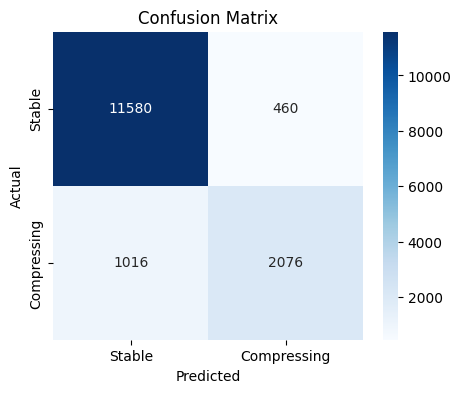

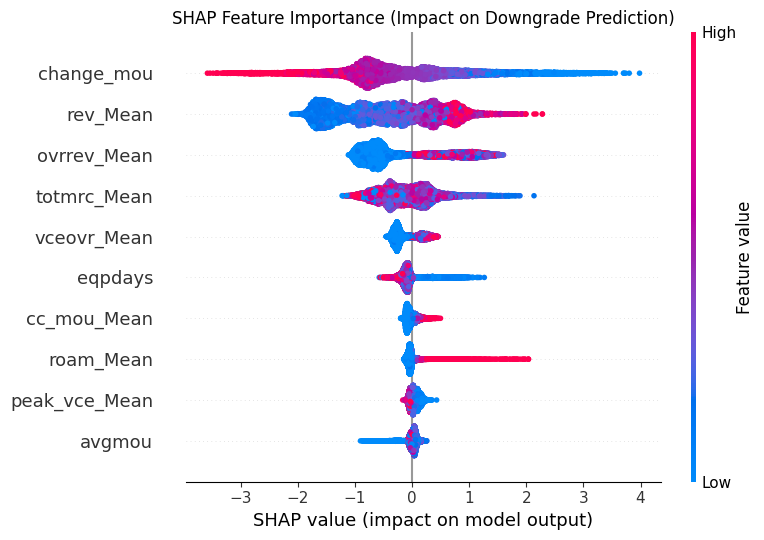

In [17]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stable', 'Compressing'], yticklabels=['Stable', 'Compressing'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# SHAP Summary Plot
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.title('SHAP Feature Importance (Impact on Downgrade Prediction)')
plt.tight_layout()
plt.show()

## 6. Business Impact & ROI Simulation
To translate model accuracy into business value, we simulate a proactive retention campaign (waiving the surprise overage fee for flagged customers). 

**Methodology:**
1. **Out-of-Fold Tuning:** To prevent threshold leakage, we use 5-fold cross-validation on the training set to find the optimal probability threshold, rather than tuning on the test set.
2. **Operational Constraint:** A Customer Success team cannot realistically call an infinite number of people. We applied a hard capacity limit, capping interventions at 15% of the customer base.
3. **Dynamic ROI:** Revenue saved is calculated dynamically using the actual historical revenue drops of the specific customers the model flagged, rather than a global average.

In [18]:
# --- 1. THRESHOLD SEARCH (on training data via CV, to avoid tuning on test set) ---
train_probs = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

train_change_rev = df.loc[X_train.index, 'change_rev']
train_ovrrev = df.loc[X_train.index, 'ovrrev_Mean']

thresholds = np.arange(0.01, 0.90, 0.02)
best_profit = -np.inf
best_thresh = 0.5

# Customer Success can only realistically handle ~15% of the base per month
max_train_capacity = int(len(X_train) * 0.15)

for thresh in thresholds:
    pred_t = (train_probs >= thresh).astype(int)
    if pred_t.sum() > max_train_capacity:
        continue

    tp_mask = (y_train == 1) & (pred_t == 1)
    fp_mask = (y_train == 0) & (pred_t == 1)

    # Benefit: 50% success rate * 12 months * actual revenue drop
    revenue_saved = train_change_rev[tp_mask].abs().sum() * 12 * 0.5
    campaign_cost = train_ovrrev[tp_mask].sum() + train_ovrrev[fp_mask].sum()

    net = revenue_saved - campaign_cost
    if net > best_profit:
        best_profit = net
        best_thresh = thresh

print(f"OPTIMAL THRESHOLD (tuned on training data): {best_thresh:.2f}")
print(f"Operational cap: max {max_train_capacity} interventions\n")


# --- 2. FINAL ROI (applied once, to unseen test data) ---
test_change_rev = df.loc[X_test.index, 'change_rev']
test_ovrrev = df.loc[X_test.index, 'ovrrev_Mean']

optimal_preds = (y_prob >= best_thresh).astype(int)
tp_mask = (y_test == 1) & (optimal_preds == 1)
fp_mask = (y_test == 0) & (optimal_preds == 1)

tp_count = tp_mask.sum()
fp_count = fp_mask.sum()

# Average loss for only the customers the model actually flagged
actual_compression_loss = test_change_rev[tp_mask].abs().mean()
annual_loss_per_customer = actual_compression_loss * 12

print(f"Avg monthly revenue drop for flagged customers: ${actual_compression_loss:.2f}")
print(f"Total flagged for intervention: {tp_count + fp_count}\n")

cost_to_save_tp = test_ovrrev[tp_mask].sum()
cost_of_false_alarms = test_ovrrev[fp_mask].sum()
total_campaign_cost = cost_to_save_tp + cost_of_false_alarms

print("SENSITIVITY ANALYSIS: ANNUAL NET PROFIT BY CAMPAIGN SUCCESS RATE (TEST SET)")
print(f"{'Success Rate':<15} | {'Customers Retained':<20} | {'Annual Revenue Saved':<25} | {'Net Profit':<15}")
print("-" * 85)

for success_rate in [0.30, 0.50, 0.70]:
    retained_customers = tp_count * success_rate
    total_annual_revenue_saved = retained_customers * annual_loss_per_customer
    net_profit = total_annual_revenue_saved - total_campaign_cost
    print(f"{success_rate*100:>13.0f}% | {int(retained_customers):>18} | ${total_annual_revenue_saved:>23,.2f} | ${net_profit:>13,.2f}")

print("\n*(Threshold was chosen assuming 50% success rate; the same threshold is reused across all sensitivity tiers for comparability.)*")

OPTIMAL THRESHOLD (tuned on training data): 0.59
Operational cap: max 5295 interventions

Avg monthly revenue drop for flagged customers: $45.72
Total flagged for intervention: 2214

SENSITIVITY ANALYSIS: ANNUAL NET PROFIT BY CAMPAIGN SUCCESS RATE (TEST SET)
Success Rate    | Customers Retained   | Annual Revenue Saved      | Net Profit     
-------------------------------------------------------------------------------------
           30% |                568 | $             311,751.23 | $   233,630.15
           50% |                947 | $             519,585.38 | $   441,464.30
           70% |               1325 | $             727,419.53 | $   649,298.45

*(Threshold was chosen assuming 50% success rate; the same threshold is reused across all sensitivity tiers for comparability.)*
